# Gibbs Sampler
In the parametric setting, we have a finite $K.$ We build a Gibbs sampler for Bayesian clustering.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

## Data generation
*The following code will be constant across the three notebooks.*

We pretend that the data is generated according to $$\pi\sim\text{Dir}(\alpha_1,\dots,\alpha_K)$$ $$z_i\sim\text{Cat}(\pi)$$ $$x_i|z_i=k \sim \mathcal{N}(\mu_k,I)$$ where we treat $K,\alpha_k$ as hyperparameters with hidden $\mu_k.$

In [2]:
# Hyperparameters
np.random.seed(14) # for reproducibility
K = 8 # number of clusters
alpha = np.random.choice(range(1,11), K) # hyperparameter for dirichlet distribution
N = 250 # number of data points
mu = np.random.uniform(-10, 10, (K, 2)) # cluster means
sigma = np.array([np.eye(2) for i in range(K)]) # cluster covariances

# Parameters for Gaussian Mixture Model
pi = np.random.dirichlet(alpha) # mixing proportions
z = np.random.choice(K, N, p=pi) # cluster assignments

# Generate data points
x = np.array([np.random.multivariate_normal(mu[z[i]], sigma[z[i]]) for i in range(N)]) # data points

In [3]:
def visualize(x, mu, z, iter):
    """
    Visualize the GMM with the current parameters
    """
    plt.scatter(x[:, 0], x[:, 1], c=z, cmap='viridis', s=50)
    plt.scatter(mu[:, 0], mu[:, 1], c='red', marker='x', s=200, label='Means')
    plt.title(f'GMM at iteration {iter}')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.colorbar(label='Cluster Assignment')
    plt.show()

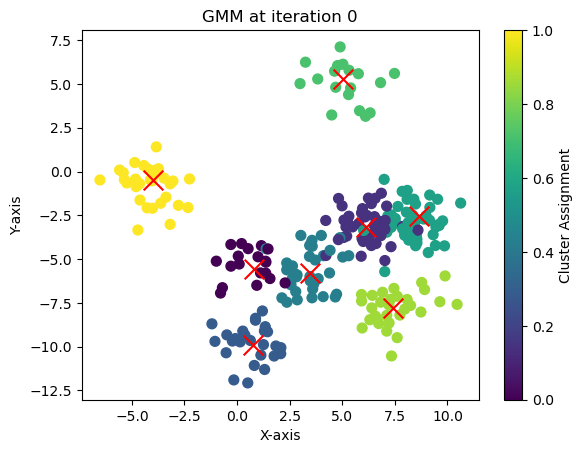

In [4]:
# Visualize the data
visualize(x, mu, z, 0)

## Parametric Gibbs Sampling
### Overview
In Gibbs sampling, we iterate over all the data some number of times, and in the process update $z_i,\hat\mu,\hat\sigma,\hat\pi$ by sampling them from an updated prior.
### Fundamentals
Recall that $$p(z_i=k|x_i,\theta)=\frac{p(x_i|z_i=k,\theta)p(z_i=k|\theta)}{\sum_{k=1}^K p(x_i|z_i=k,\theta)p(z_i=k|\theta)}=\frac{\mathcal{N}(\hat\mu_k,I)\hat\pi_k}{\sum_{k=1}^K\mathcal{N}(\hat\mu_k,I)\hat\pi_k}.$$

The posterior destribution we seek is $$p(z_i,\theta,\pi|x_i).$$ Gibbs Sampling tells us that instead of sampling directly from this joint distribution, we may sample $$z_i\sim p(z_i|x_i,\pi,\theta)$$ $$\theta\sim p(\theta|z_i,x_i,\pi)$$ $$\pi\sim p(\pi|\theta,z_i,x_i).$$
### Sampling $z_i$
We sample from $$p(z_i|x_i,\pi,\theta) = p(z_i|x_i,\theta) = \sum_{k=1}^K p(z_i=k|x_i,\theta) = \sum_{k=1}^K \frac{\mathcal{N}(\hat\mu_k,I)\hat\pi_k}{\sum_{k=1}^K\mathcal{N}(\hat\mu_k,I)\hat\pi_k}.$$
### Sampling $\theta$
For our purposes, note that $\theta=(\mu_k)_{k=1}^K.$ Then for any given $\mu_k,$ $$p(\mu_k|z_i=k,x_i,\pi) = p(\mu_k|z_i=k,x_i)=\mathcal{N}\left(\frac{1}{N_k}\sum_{i=1}^n x_i\mathbb{1}_{z_i=k}, I_k\right).$$ Intuitively, for any given cluster, we sample from a normal distribution centered at the average of all the points that are in the cluster. Repeat for all clusters.

(Note that by ignoring standard deviation, our cluster centers may not be intuitive - a fix would be to allow standard deviation to change, or, alternatively, simply force each $\mu_k$ to be the average of the points in the cluster)
### Sampling $\pi$
We sample from $$p(\pi|z_i,x_i,\theta) = \text{Dir}(\alpha_1 + N_1,\dots,\alpha_K + N_K).$$

In [5]:
np.random.seed(14) # for reproducibility
# Priors
alpha_hat = np.ones(K) # prior for dirichlet distribution
pi_hat = np.random.dirichlet(alpha_hat) # prior for mixing proportions
z_hat = np.random.choice(K, N, p=pi) # prior for cluster assignments

# Initialize parameters
mu_hat = x[np.random.choice(range(250), K)] # cluster means
sigma_hat = np.array([np.eye(2) for _ in range(K)]) # cluster covariances

In [6]:
# Gibbs Sampling loop
def gibbs(x, mu_hat, pi_hat, z_hat, alpha, K, N):
    """
    A single iteration of the Gibbs Sampling algorithm
    """
    # Update cluster assignments
    for i in range(N):
        responsibilities = np.array([pi_hat[k] * multivariate_normal.pdf(x[i], mean=mu_hat[k], cov=sigma_hat[k]) for k in range(K)])
        responsibilities /= np.sum(responsibilities)
        z_hat[i] = np.random.choice(K, p=responsibilities)

    # Update cluster means
    for k in range(K):
        x_k = x[z_hat == k]
        if len(x_k) > 0:
            mu_hat[k] = np.random.multivariate_normal(np.mean(x_k, axis=0), np.eye(2)*0.4)
        else:
            mu_hat[k] = np.random.multivariate_normal(np.mean(x, axis=0), np.eye(2))

    # Update cluster mixtures
    pi_hat = np.random.dirichlet(alpha + np.bincount(z_hat, minlength=K))

    return mu_hat, pi_hat, z_hat

## Results

We visualize the results of EM at different stages.

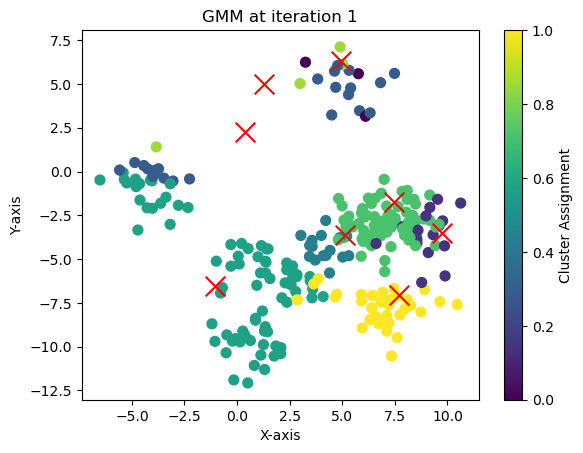

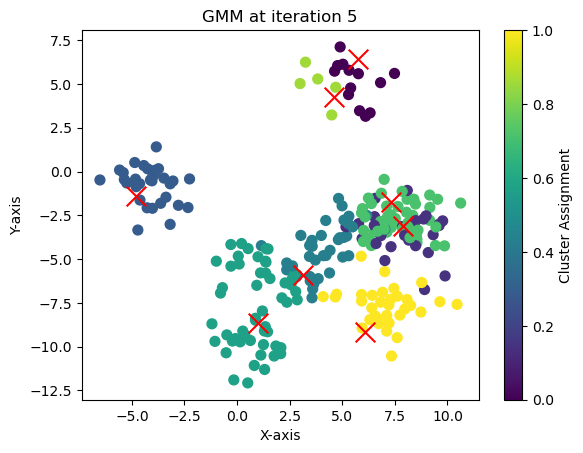

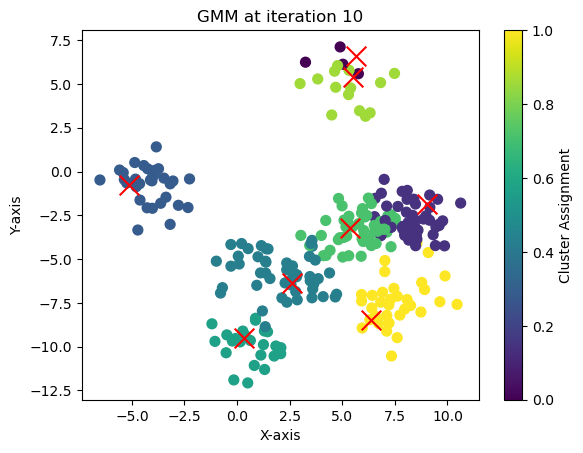

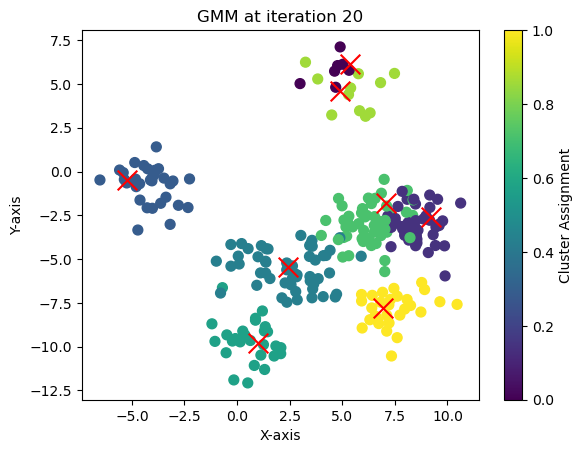

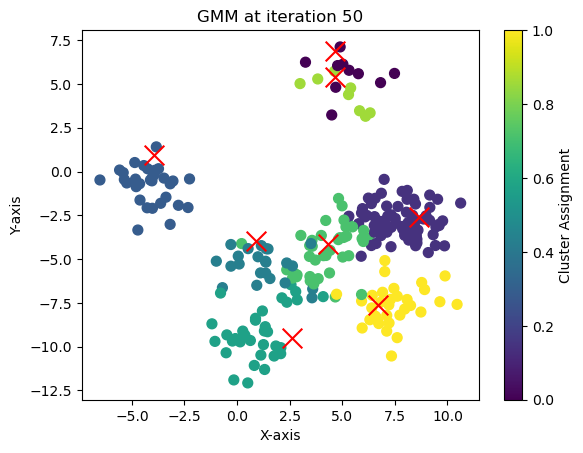

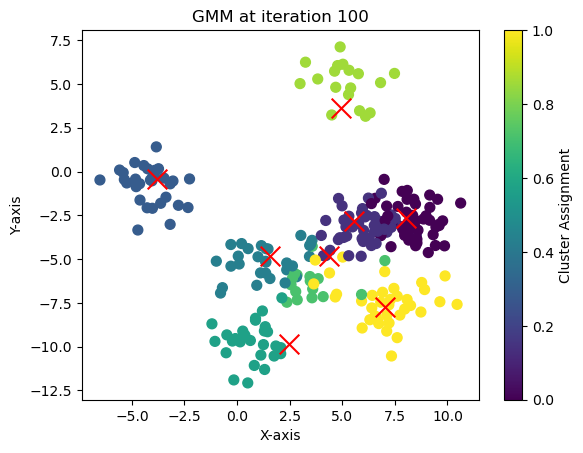

In [7]:
np.random.seed(17) # for reproducibility
# Snapshots of parameters
snapshots = [1, 4, 5, 10, 30, 50]
# Run EM algorithm
for idx, itr in enumerate(snapshots):
    for i in range(itr):
        mu_hat, pi_hat, z_hat = gibbs(x, mu_hat, pi_hat, z_hat, alpha, K, N)
    # Visualize the current state
    visualize(x, mu_hat, z_hat, sum(snapshots[:idx+1]))

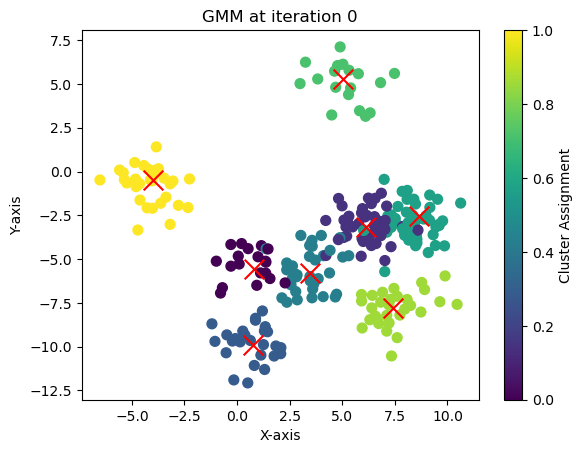

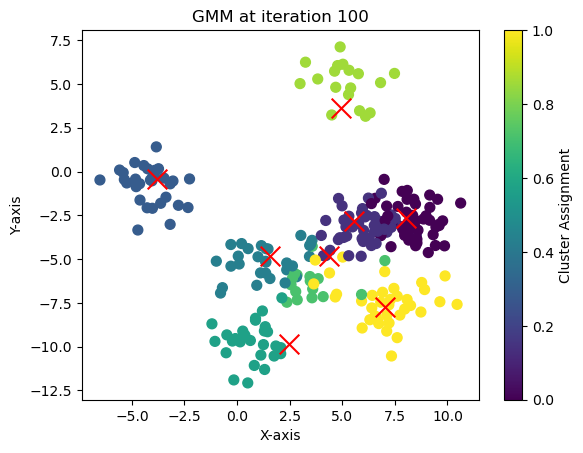

In [8]:
visualize(x, mu, z, 0)
visualize(x, mu_hat, z_hat, sum(snapshots))